In [11]:
%pip install numpy matplotlib scipy scikit-learn kagglehub pandas seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, kv
import scipy.stats as stats

# Задание 1

# Вариант

*самая сложная часть*

In [13]:
ALPHABET = "АБВГДЕЁЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯ"

In [14]:
first_letter_bobrov_index = ALPHABET.index("Б") + 1
first_letter_chunikhina_index = ALPHABET.index("Ч") + 1

In [15]:
mean_index = (first_letter_bobrov_index + first_letter_chunikhina_index) // 2

In [16]:
print(f"Вариант: {mean_index % 2 + 1}")

Вариант: 2


Итого Вариант 2

Соответствующие данные:
$$\operatorname{Exp}(\theta);\ \Gamma(k, \lambda);\ \lambda=k=1$$

# Пункт 1

## Функция правдеподобия

Так как мы предполагаем, что выполнено условие независимости выборки, то функция правдоподобия будет выглядеть следующим образом

$$
\operatorname{L}(\theta)=\prod^n_{i=1}p(x_i|\theta)
$$

Введем параметризацию и выразим $p(x)$ как:
$$
p(x)=\theta^{-1}e^{-x/\theta}
$$

Тогда функция правдоподобия будет выглядеть следующим образом:
$$
\operatorname{L}(\theta)=\prod^n_{i=1}\theta^{-1}e^{-x_i/\theta}=\theta^{-n}e^{\sum_{i=1}^n -x_i/\theta}=\theta^{-n} \exp \left(-\frac{\sum_{i=1}^n x_i}{\theta}\right)
$$

Для упрощения дальнейшего исчисления используем логарифм:
$$
\ell(\theta)=-n \ln \theta - \frac{\sum_{i=1}^n x_i}{\theta}
$$

## Нахождение максимума функции правдоподобия

Теперь найдем производную и соответствующий максимум данной функции – это и будет теоретическая оценка параметра $\theta$

$$
-\frac{n}{\theta}+\frac{\sum_{i=1}^n x_i}{\theta^2}=0
$$

Домножаем на $\theta$, переносим в одну часть и получаем теоретическую оценку параметра:
$$
\hat{\theta}_{\operatorname{MLE}}=\frac{\sum x_i}{n}
$$

## Нахождение теоретического математического ожидания

$$
\hat{\theta}=\frac{1}{n}\sum_{i=1}^n x_i \Rightarrow \mathbb{E}[\hat{\theta}]=\frac{1}{n}\sum \mathbb{E}[x_i]
$$

Для нашего распределения и того, как мы его ввели мат ожидание будет следующим: $\mathbb{E}[x]=\theta$

Следовательно,
$$
\mathbb{E}[\hat{\theta}]=\frac{1}{n} \cdot n \theta = \theta
$$

## Нахождение смещения

$$\operatorname{Bias}(\hat{\theta})=\mathbb{E}[\hat{\theta}]-\theta=\theta-\theta=0$$

Следовательно, наша оценка – несмещенная

## Нахождение дисперсии

$$
\operatorname{Var}(\hat{\theta})=\operatorname{Var} \left(\frac{1}{n}\sum_{i=1}^n x_i\right)
$$

По свойствам дисперсии выводим:
$$
\operatorname{Var} \left(\frac{1}{n}\sum_{i=1}^n x_i\right)=\frac{1}{n^2} \sum_{i=1}^n \operatorname{Var}(x_i)
$$

По теории у нас дисперсия равна $\theta^2$, следовательно:
$$
\operatorname{Var}(\hat{\theta})=\frac{\theta^2}{n}
$$

## MSE

MSE удобно находить через разложение через Var и Bias
$$
\operatorname{MSE}(\hat{\theta})=\operatorname{Var}(\hat{\theta}) + \operatorname{Bias}(\hat{\theta})^2=\frac{\theta^2}{n}
$$

# Пункт 2

## Априорное распределение

Найдем априорное распределение для нашей оценки

$$
p(\theta)=\frac{\lambda^{-k}\theta^{k - 1}e^{-\theta/\lambda}}{\Gamma(k)}=\frac{1^{-1}\theta^{1-1}e^{-\theta}}{\Gamma(1)}=e^{-\theta}
$$

## Апостериорная плотность

$$
p(\theta | X) = \frac{\theta^{-n} \exp \left( -\frac{\sum x_i}{\theta} - \theta \right)}{\int \theta^{-n} \exp \left( -\frac{\sum x_i}{\theta} - \theta \right)d\theta}
$$

Возьмем стандартную квадратическую функцию потерь. Так как для нее верно следующее:
$$
\hat{\theta_B}=\mathbb{E}[\theta|X]
$$

То можем вычислить теоретическую оценку параметра:
$$
\hat{\theta_B}=\frac{\int_0^\infty\theta \cdot \theta^{-n} \exp \left( -\frac{\sum x_i}{\theta} - \theta \right)d\theta}{\int \theta^{-n} \exp \left( -\frac{\sum x_i}{\theta} - \theta \right)d\theta}
$$

## Подсчет оценок

Получившийся результат является обобщенным обратным гауссовским распределением (GIG). Информация о нем и в дальнейшем была найдена в этой [статье](https://en.wikipedia.org/wiki/Generalized_inverse_Gaussian_distribution).

Так как наша апостериорная плотность:
$$
p(\theta | X) \propto \theta^{-n} \exp \left( -\frac{\sum x_i}{\theta} - \theta \right)
$$

А GIG:
$$
f(x)=\frac{(a/b)^{p/2}}{2K_p(\sqrt{ab})}x^{p-1}e^{-(ax+b/x)/2}
$$

Рассмотрим ядро распределения GIG (часть без нормировочной константы)
$$
p(\theta)=\theta^{p-1}\exp\left(-\frac{a\theta}{2}-\frac{b}{2\theta}\right)
$$

Итого, получаем:
$$
p=1-n\qquad b=2\sum x_i \qquad a=2
$$

## Мат ожидание

Мат ожидание GIG:
$$
\mathbb{E}[\hat{\theta}]=\sqrt{\frac{b}{a}}\frac{K_{p+1}(\sqrt{ab})}{K_p(\sqrt{ab})}
$$

Для нашей конкретно задачи:
$$
\mathbb{E}[\hat{\theta}]=\sqrt{\sum x_i}\frac{K_{2-n}(2\sqrt{\sum x_i})}{K_{1-n}(2 \sqrt{\sum x_i})}
$$

## Смещение

$$
\operatorname{Bias}(\hat{\theta})=\mathbb{E}[\hat{\theta}]-\theta=\sqrt{\sum x_i}\frac{K_{2-n}(2\sqrt{\sum x_i})}{K_{1-n}(2 \sqrt{\sum x_i})}-\theta
$$

Заметим, что одно при $n \rightarrow \infty$ выполняется $\sum x_i \approx n\theta$, и одно из свойств функции Бесселя – $\frac{K_{p+1}(n)}{K_{p}(n)}$. Следовательно, байесовская оценка будет несмещённой только асимптотически:
$$
\operatorname{Bias} \rightarrow 0
$$

## Дисперсия

Теоретическая дисперсия расписывается через соответствующие моменты:
$$
\operatorname{Var}(\theta|X)=\mathbb{E}[\theta^2|X]-(\mathbb{E}[\theta|X])^2
$$

Интегрируя получаем формулу для моментов:
$$
\mathbb{E}[\theta^k|X]=(\sqrt{b/a})^k \frac{K_{p+k}(\sqrt{ab})}{K_{p}(\sqrt{ab})}
$$

Исходя из этого получим выражение для дисперсии:
$$
\operatorname{Var}(\theta)=\sum x_i \left( \frac{K_{3-n}(2\sqrt{\sum x_i})}{K_{1-n}(2\sqrt{\sum x_i})} - \left( \frac{K_{2-n}(2\sqrt{\sum x_i})}{K_{1-n}(2\sqrt{\sum x_i})} \right)^2 \right)
$$

Аналитически высчитать это я не берусь, не факт, что аналитически это возможно, так что будем действовать способом асимптотическим

### Теорема Бернштейна-фон Мизеса

Для нахождения асимптотического значения дисперсии воспользуемся [теоремой Бернштейна-фон Мизеса](https://www.google.com/search?client=safari&rls=en&q=bernstein+von+mises+theorem&ie=UTF-8&oe=UTF-8).

Данная теорема описывает поведение апостериорного распределения при $n \rightarrow \infty$. Согласно ей, при выполнении нескольких условий регулярности, апостериорное распределение сходится по вероятности к нормальному распределению:
$$
p(\theta|X) \rightarrow \mathcal{N}\left(\hat{\theta}_{\operatorname{MLE}}, \frac{1}{nI(\theta_0)}\right)
$$

Где $\hat{\theta}_{\operatorname{MLE}}$ – оценка максимального правдоподобия, $\theta_0$ – true population parameter, $I(\theta_0)$ – информация Фишера

### Условия выполнения теоремы:

1. Model admits densities

Модель должна быть корректно определена и работать относительно некоторой меры. Грубо говоря, это значит, что требуется наличие плотности для всех возможных парамтеров. Для дискретных распределений это не работает, например. Наша модель (так называют в данном тексте правдоподобие) имеет открытое подмножество $R^1$ как параметрическое пространство $[0, \infty)$, очевидно, что для каждого параметра данное условие выполняется

2. Fisher information matrix

Матрица Фишера должна быть невырожденной. У нас матрица Фишера представляет собой одно число и равняется $1/\theta^2$, а значит условие выполняется

3. The model is differentiable in quadratic mean

Требуется, чтобы при малых изменениях параметров плотность менялась плавно в смысле L2-нормы.
$$
\int \left[ \sqrt{p_{\theta}(x)} - \sqrt{p_{\theta_0}(x)} - \frac{1}{2}(\theta - \theta_0)^\top f(x) \sqrt{p_{\theta_0}(x)} \right]^2 \mathrm{d}\mu(x) = o(||\theta - \theta_0||^2) \text{ при } \theta \to \theta_0
$$
Выполнение условия обусловлено тем, что экспоненциальное распределение интегрируемо и дифференцируемо сколько угодно раз, логарифм плотности является гладкой функцией.

4. Наличие решающих функций

Требуется существование последовательности статистических критериев, способных безошибочно отличить истинное значение параметра от любого знасчения $\theta$, лежащего за пределом эпсилон-окрестности. Так как в нашей задаче мы используем экспоненциальное распределение, то его логарифмическое правдоподобие будет строго вогнуто и иметь глобальный максимум.

5. Приорное распределение

Приорное распределение должно быть абсолютно непрерывным по мере Лебега в окрестности $\theta_0$ и иметь положительную плотность в этой точке и в окрестности. У нас prior задан как $e^{-\theta}$: всегда положительно, везде непрерывно, на этом разбор условий давайте закончим.

Условия теоремы выполняются, а значит можно приступить к вычислению дисперсии. Как выяснилось, она асимптотически:
$$
\operatorname{Var}(\hat{\theta}) \approx \frac{1}{n I(\theta)}
$$

Сначала найдем информацию Фишера.
$$
\ln p_{\theta}(x)=-\ln \theta - x/\theta
$$
$$
I(\theta)=-\mathbb{E}\left[ \frac{d^2}{d\theta^2} (-\ln \theta - x/\theta) \right]=-\mathbb{E}\left[ 1/\theta^2 - \frac{2x}{\theta^3} \right]=\frac{1}{\theta^2}
$$

По итогу,
$$
\operatorname{Var}(\hat{\theta})=\frac{\theta^2}{n}
$$

## MSE

$$
\operatorname{MSE}(\hat{\theta})=\mathbb{E}[(\hat{\theta}-\theta_0)^2]=\operatorname{Var}(\hat{\theta})+\operatorname{Bias}(\hat{\theta}, \theta_0)^2
$$

Опять же, теоретически вычислить не можем, но асимптотически получаем:
$$
\operatorname{MSE}=\frac{\theta^2}{n}
$$

## Пункт 3

In [17]:
sample_sizes = [5, 20, 100, 1000, 5000, 50000]

In [18]:
import numpy as np
from scipy.special import kv

def run_experiment(sample_sizes: list[int], theta_true: float, iterations: int) -> dict:
    results = {}

    for sample_size in sample_sizes:
        mle_estimates = []
        bayes_estimates = []

        for _ in range(iterations):
            x = np.random.exponential(theta_true, sample_size)
            sum_x = np.sum(x)

            theta_mle = sum_x / sample_size
            mle_estimates.append(theta_mle)

            if sample_size > 200:
                theta_b = theta_mle
            else:
                p = 1 - sample_size
                b = 2
                a = sum_x * 2
                sqrt_ab = np.sqrt(a * b)

                k_p_plus_1 = kv(p + 1, sqrt_ab)
                k_p = kv(p, sqrt_ab)

                if np.isinf(k_p_plus_1) or np.isinf(k_p) or k_p == 0:
                    theta_b = theta_mle
                else:
                    theta_b = np.sqrt(b/a) * (k_p_plus_1 / k_p)

            bayes_estimates.append(theta_b)

        estimates = {"MLE": np.array(mle_estimates), "Bayes": np.array(bayes_estimates)}
        n_results = {}

        for name, est in estimates.items():
            mean = np.mean(est)
            bias = np.mean(est) - theta_true
            variance = np.var(est)
            mse = np.mean((est - theta_true) ** 2)
            n_results[name] = {'Mean': mean, 'Bias': bias, 'Var': variance, 'MSE': mse}

        results[sample_size] = n_results
    return results

In [19]:
results = run_experiment(sample_sizes=[5, 20, 100, 1000, 5000], theta_true=5.0, iterations=100)

In [20]:
results

{5: {'MLE': {'Mean': np.float64(5.16588571230837),
   'Bias': np.float64(0.1658857123083699),
   'Var': np.float64(5.3144790171756835),
   'MSE': np.float64(5.34199708672374)},
  'Bayes': {'Mean': np.float64(0.14793270446086565),
   'Bias': np.float64(-4.852067295539134),
   'Var': np.float64(0.0005003327551499003),
   'MSE': np.float64(23.543057373195595)}},
 20: {'MLE': {'Mean': np.float64(4.942165685190462),
   'Bias': np.float64(-0.057834314809538157),
   'Var': np.float64(0.8442225129446872),
   'MSE': np.float64(0.8475673209141762)},
  'Bayes': {'Mean': np.float64(0.0444242622492057),
   'Bias': np.float64(-4.955575737750794),
   'Var': np.float64(1.8228540071682928e-06),
   'MSE': np.float64(24.557732715438338)}},
 100: {'MLE': {'Mean': np.float64(4.985740314044401),
   'Bias': np.float64(-0.01425968595559901),
   'Var': np.float64(0.22281541905298372),
   'MSE': np.float64(0.223018757696536)},
  'Bayes': {'Mean': np.float64(0.009719374886664712),
   'Bias': np.float64(-4.990280

Отличные результаты, работает

# Пункт 4

In [21]:
def posterior_grid(x, grid_size=20000):
    n = len(x)
    sum_x = np.sum(x)
    mode = (np.sqrt(n ** 2 + 4 * sum_x) - n) / 2
    second_derivative = n / mode ** 2 - 2 * sum_x / mode ** 3
    scale = np.sqrt(-1 / second_derivative)
    lower = max(mode - 8 * scale, 1e-6)
    upper = mode + 8 * scale
    theta_grid = np.linspace(lower, upper, grid_size)
    log_density = -n * np.log(theta_grid) - sum_x / theta_grid - theta_grid
    density = np.exp(log_density - np.max(log_density))
    density = density / np.trapezoid(density, theta_grid)
    cdf = np.concatenate(([0], np.cumsum((density[1:] + density[:-1]) / 2 * np.diff(theta_grid))))
    cdf = cdf / cdf[-1]
    return theta_grid, density, cdf

In [22]:
def equal_tailed_interval(theta_grid, cdf, alpha=0.05):
    return np.interp(alpha / 2, cdf, theta_grid), np.interp(1 - alpha / 2, cdf, theta_grid)

In [23]:
def high_density_interval(theta_grid, cdf, alpha=0.05, grid_size=10000):
    left_probs = np.linspace(0, alpha, grid_size)
    right_probs = left_probs + 1 - alpha
    lows = np.interp(left_probs, cdf, theta_grid)
    highs = np.interp(right_probs, cdf, theta_grid)
    widths = highs - lows
    best = np.argmin(widths)
    return lows[best], highs[best]

In [24]:
n = 100
theta_true = 20.0
x = np.random.exponential(theta_true, n)
theta_grid, density, cdf = posterior_grid(x)

et_low, et_high = equal_tailed_interval(theta_grid, cdf)
hdi_low, hdi_high = high_density_interval(theta_grid, cdf)

print(f"95% Equal-tailed credible interval (n={n}): [{et_low:.3f}, {et_high:.3f}]")
print(f"95% High-density credible interval (n={n}): [{hdi_low:.3f}, {hdi_high:.3f}]")

95% Equal-tailed credible interval (n=100): [16.129, 22.546]
95% High-density credible interval (n=100): [15.975, 22.357]


In [25]:
def plot_credible_intervals(theta_grid, density, theta_true, equal_tailed, high_density, alpha=0.05):
    plt.figure(figsize=(10, 6))
    plt.plot(theta_grid, density, color='blue', linewidth=2, label='Апостериорное распределение')

    et_low, et_high = equal_tailed
    hdi_low, hdi_high = high_density

    et_mask = (theta_grid >= et_low) & (theta_grid <= et_high)
    hdi_mask = (theta_grid >= hdi_low) & (theta_grid <= hdi_high)

    posterior_mean = np.trapezoid(theta_grid * density, theta_grid)

    plt.fill_between(theta_grid, density, where=et_mask, color='skyblue', alpha=0.35, label=f'{int((1-alpha)*100)}% equal-tailed')
    plt.fill_between(theta_grid, density, where=hdi_mask, color='orange', alpha=0.35, label=f'{int((1-alpha)*100)}% HDI')

    plt.axvline(theta_true, color='red', linestyle='--', label=f'Истинное θ = {theta_true}')
    plt.axvline(posterior_mean, color='green', linestyle=':', label=f'Байесовская оценка = {posterior_mean:.3f}')
    plt.axvline(et_low, color='deepskyblue', linestyle='--')
    plt.axvline(et_high, color='deepskyblue', linestyle='--')
    plt.axvline(hdi_low, color='darkorange', linestyle='--')
    plt.axvline(hdi_high, color='darkorange', linestyle='--')

    plt.title(f'Credible intervals для апостериорного распределения (n={n})')
    plt.xlabel('Параметр θ')
    plt.ylabel('Плотность вероятности')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

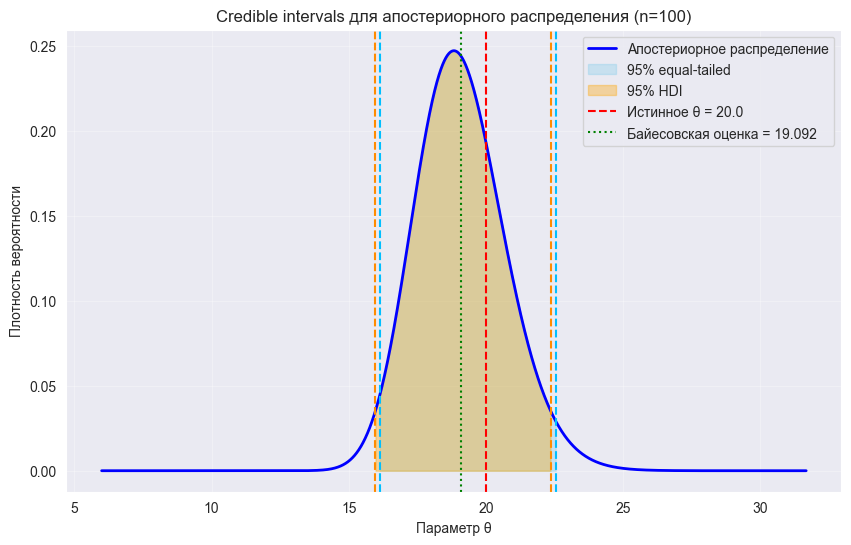

In [26]:
plot_credible_intervals(theta_grid, density, theta_true, (et_low, et_high), (hdi_low, hdi_high))

95% Equal-tailed credible interval (n=5000): [19.223, 20.314]
95% High-density credible interval (n=5000): [19.218, 20.309]


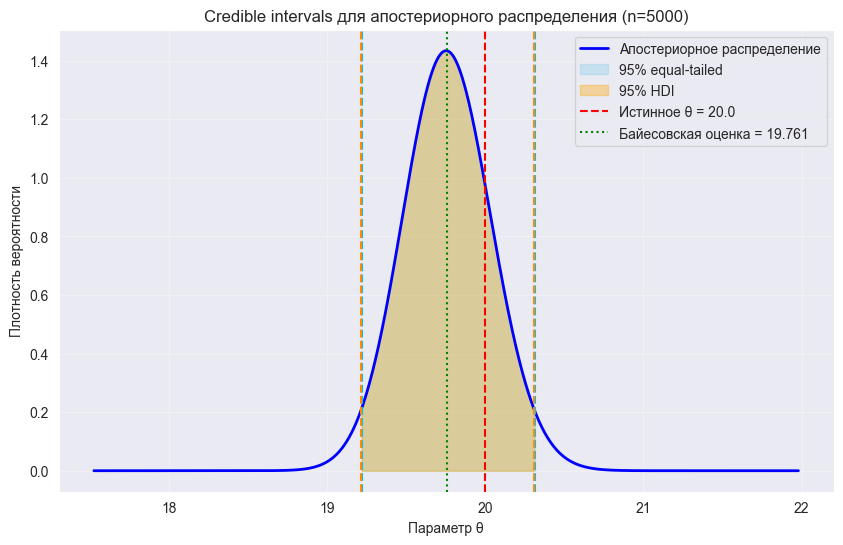

In [27]:
n = 5000
x = np.random.exponential(theta_true, n)
theta_grid, density, cdf = posterior_grid(x)

et_low, et_high = equal_tailed_interval(theta_grid, cdf)
hdi_low, hdi_high = high_density_interval(theta_grid, cdf)

print(f"95% Equal-tailed credible interval (n={n}): [{et_low:.3f}, {et_high:.3f}]")
print(f"95% High-density credible interval (n={n}): [{hdi_low:.3f}, {hdi_high:.3f}]")
plot_credible_intervals(theta_grid, density, theta_true, (et_low, et_high), (hdi_low, hdi_high))

# Задание 2

In [28]:
import kagglehub
import os
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif


Загружаем датасет

In [29]:
path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

csv_path = os.path.join(path, "adult.csv")
df = pd.read_csv(csv_path)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [30]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


Удаляем ненужную переменную fnlwgt, т к она показывает количество опрашиваемых людей с такими же данными

In [31]:
data = df.copy()
if 'fnlwgt' in data.columns:
    data = data.drop(columns=['fnlwgt'])

Проверяем зависимость каждого признака, сначала категориальных по хи-квадрат тесту, а потом численных по т-тесту

In [32]:
categorical_features = ['gender', 'race', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'native-country']

target = 'income'

selected_features = []

for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df[target])

    chi2, p, dof, ex = chi2_contingency(contingency_table)

    status = "Зависим (Полезен)" if p < 0.05 else "Независим (Бесполезен)"

    print(f"Признак: {col:15} | P-value: {p:.4e} | Статус: {status}")

    if p < 0.05:
        selected_features.append(col)

print("\nОтобранные признаки:", selected_features)

Признак: gender          | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: race            | P-value: 4.2844e-104 | Статус: Зависим (Полезен)
Признак: workclass       | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: education       | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: marital-status  | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: occupation      | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: relationship    | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: native-country  | P-value: 1.0356e-70 | Статус: Зависим (Полезен)

Отобранные признаки: ['gender', 'race', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'native-country']


In [33]:
num_features = ['age', 'educational-num', 'hours-per-week', "capital-gain", "capital-loss"]
target = 'income'

print("Результаты T-теста для числовых признаков:\n")

for col in num_features:
    # Разделяем данные на две группы по доходу
    group1 = df[df[target] == '<=50K'][col]
    group2 = df[df[target] == '>50K'][col]

    # Проводим T-тест
    t_stat, p = ttest_ind(group1, group2)

    status = "Зависим (Полезен)" if p < 0.05 else "Независим (Бесполезен)"
    print(f"Признак: {col:15} | P-value: {p:.4e} | Статус: {status}")

    if p < 0.05:
        selected_features.append(col)

print("\nОтобранные признаки:", selected_features)

Результаты T-теста для числовых признаков:

Признак: age             | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: educational-num | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: hours-per-week  | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: capital-gain    | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: capital-loss    | P-value: 8.5436e-236 | Статус: Зависим (Полезен)

Отобранные признаки: ['gender', 'race', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'native-country', 'age', 'educational-num', 'hours-per-week', 'capital-gain', 'capital-loss']


Кодируем категориальную переменную в 0 и 1

In [34]:
le_target = LabelEncoder()
data['income'] = le_target.fit_transform(data['income'])

Переводим остальные категориальные переменные в цифры

In [35]:
categorical_cols = data.select_dtypes(include=['object']).columns
le_features = LabelEncoder()

for col in categorical_cols:
    data[col] = le_features.fit_transform(data[col])

/var/folders/wd/kkhq0f3j3zb4kldckj6smtlr0000gn/T/ipykernel_32559/3799740633.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=['object']).columns


In [36]:
X = data.drop(columns=['income'])
y = data['income']

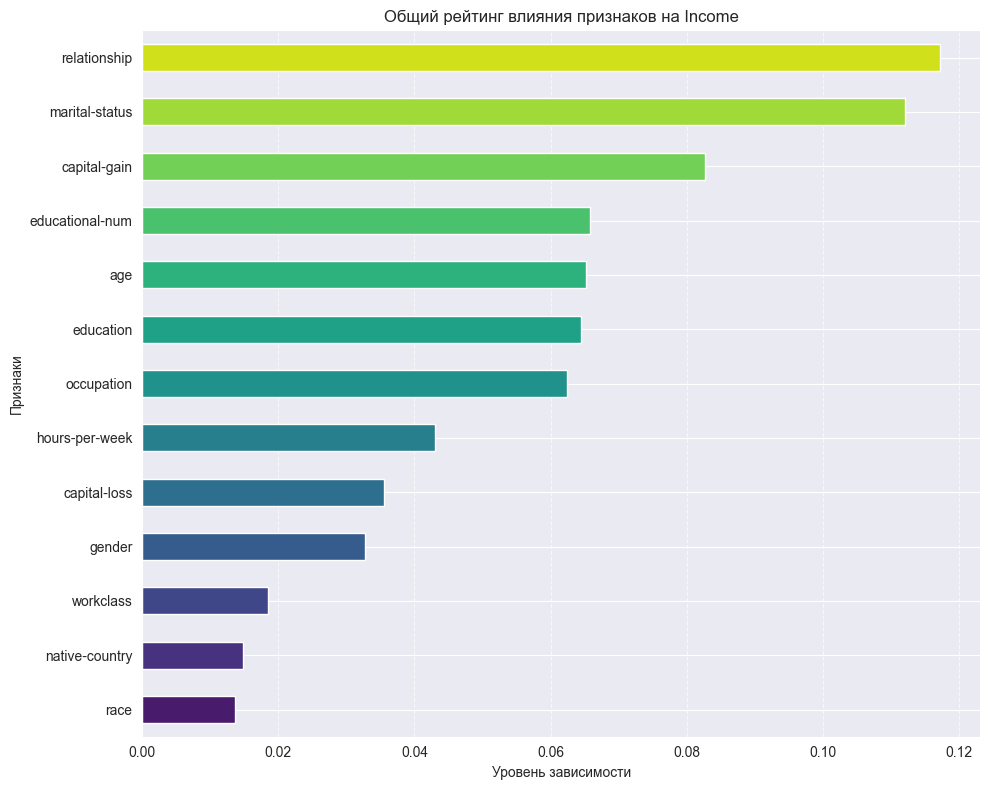

In [37]:
discrete_features = [X.columns.get_loc(col) for col in categorical_features]

importances = mutual_info_classif(X, y, random_state=42)

feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = sns.color_palette("viridis", len(feature_importance))
feature_importance.plot(kind='barh', color=colors)

plt.title('Общий рейтинг влияния признаков на Income')
plt.xlabel('Уровень зависимости')
plt.ylabel('Признаки')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

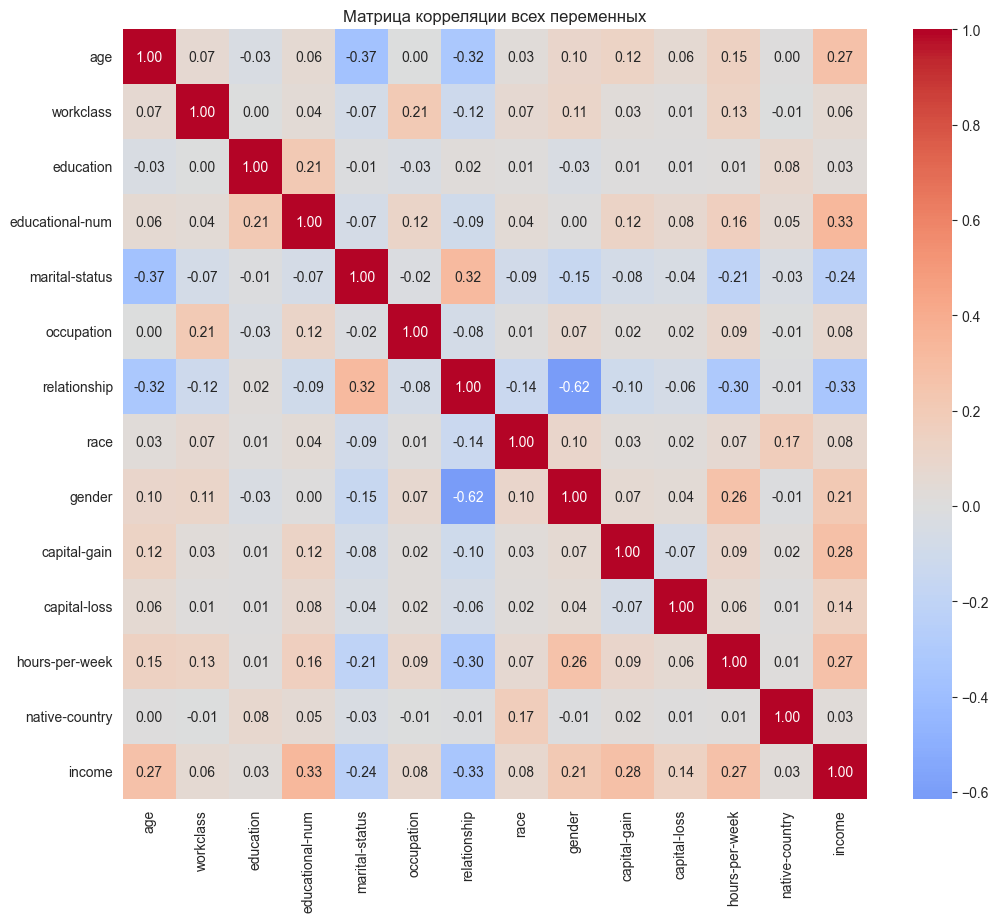

In [38]:
corr_matrix = data.corr(method='spearman')

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Матрица корреляции всех переменных')
plt.show()

Делим на атрибуты на подклассы. Делим по логике, 1ая группа будет отвечать за демографические признаки, 2ая за профессиональные, 3я за финансовую историю + два пересекающихся признака с остальными подклассами

In [39]:
C1 = ['age', 'gender', 'race', 'native-country', 'relationship']
C2 = ['workclass', 'educational-num', 'occupation', 'hours-per-week', 'marital-status']
C3 = ['capital-gain', 'capital-loss', 'hours-per-week', 'age']

Видим дисбаланс классов

In [40]:
data['income'].value_counts()

income
0    37155
1    11687
Name: count, dtype: int64

Делим на обучающую и тестовую выборки

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Обучаем наивный Гауссовский Байесовский классификатор

In [42]:
def evaluate_model(feature_list, name):
    print(f"\n--- Анализ модели: {name} ---")

    model = GaussianNB()
    model.fit(X_train[feature_list], y_train)

    y_pred = model.predict(X_test[feature_list])

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

    return model

In [43]:
nb_model_1 = evaluate_model(C1, "C1 (Демография)")


--- Анализ модели: C1 (Демография) ---
Accuracy: 0.7564
              precision    recall  f1-score   support

       <=50K       0.86      0.81      0.84      7479
        >50K       0.48      0.58      0.53      2290

    accuracy                           0.76      9769
   macro avg       0.67      0.69      0.68      9769
weighted avg       0.77      0.76      0.76      9769



In [44]:
nb_model_2 = evaluate_model(C2, "C2 (Профессия)")


--- Анализ модели: C2 (Профессия) ---
Accuracy: 0.8243
              precision    recall  f1-score   support

       <=50K       0.85      0.93      0.89      7479
        >50K       0.68      0.48      0.56      2290

    accuracy                           0.82      9769
   macro avg       0.76      0.71      0.73      9769
weighted avg       0.81      0.82      0.81      9769



In [45]:
nb_model_3 = evaluate_model(C3, "C3 (Финансы)")


--- Анализ модели: C3 (Финансы) ---
Accuracy: 0.7989
              precision    recall  f1-score   support

       <=50K       0.82      0.95      0.88      7479
        >50K       0.65      0.31      0.42      2290

    accuracy                           0.80      9769
   macro avg       0.73      0.63      0.65      9769
weighted avg       0.78      0.80      0.77      9769



Самая большая точность получилась на 2ом подклассе, тут самый высокий баланс точности.

У модели на 1ом подклассе самая низкая точность, но самый высокий recall для класса >50K (0.48). Это значит, что она склонна чаще называть людей богатыми, но при этом она часто ошибается (precision для >50K = 0.48).


Модель на 3ем подклассе хорошо находит людей с низким доходом (recall для <=50K = 0.95), но плохо выделяет богатых (recall для >50K всего 0.31). Это связано с тем, что данные о прибыли (capital-gain) очень разряжены.

In [46]:
def plot_conf_matrix(model, feature_list, name):
    y_pred = model.predict(X_test[feature_list])
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['<=50K', '>50K'],
                yticklabels=['<=50K', '>50K'])
    plt.title(f'Матрица ошибок: {name}')
    plt.ylabel('Реальность')
    plt.xlabel('Предсказание')
    plt.show()

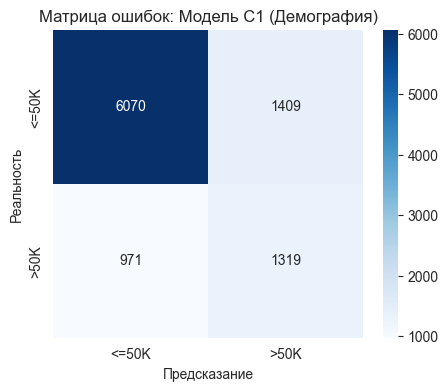

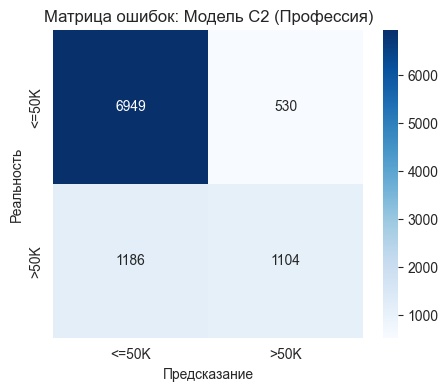

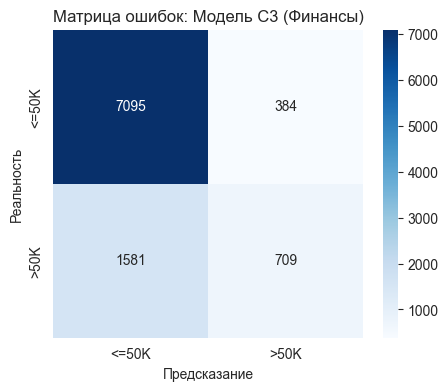

In [47]:
plot_conf_matrix(nb_model_1, C1, "Модель C1 (Демография)")
plot_conf_matrix(nb_model_2, C2, "Модель C2 (Профессия)")
plot_conf_matrix(nb_model_3, C3, "Модель C3 (Финансы)")

In [48]:
def calculate_log_likelihood(model, feature_list, X_test_df, y_test_series):
    jll = model._joint_log_likelihood(X_test_df[feature_list])

    actual_log_probs = []
    for i, target_class in enumerate(y_test_series):
        actual_log_probs.append(jll[i, target_class])

    total_ll = np.sum(actual_log_probs)
    return total_ll

In [49]:
ll1 = calculate_log_likelihood(nb_model_1, C1, X_test, y_test)
ll2 = calculate_log_likelihood(nb_model_2, C2, X_test, y_test)
ll3 = calculate_log_likelihood(nb_model_3, C3, X_test, y_test)

print(f"Total Log-Likelihood C1: {ll1:.2f}")
print(f"Total Log-Likelihood C2: {ll2:.2f}")
print(f"Total Log-Likelihood C3: {ll3:.2f}")

Total Log-Likelihood C1: -114894.20
Total Log-Likelihood C2: -128410.53
Total Log-Likelihood C3: -240925.34


По правдоподобию модель на C1 лучше. Можем предположить это связано с тем, что возраст и демографические данные распределены более плавно, и Гауссовскому классификатору легче их описывать. А на C2 модель имеет более высокую точность, потому что признаки (образование, работа) информативнее для предсказания дохода, но не идеально соответствуют нормальному распределению.

Попробуем обучит наивный категориальный байес только для категориальных признаков из 2го подкласса

In [50]:
C4 = ['relationship', 'marital-status', 'education', 'occupation', 'native-country', 'workclass', 'race']

In [51]:
model = CategoricalNB()
model.fit(X_train[C4], y_train)

y_pred = model.predict(X_test[C4])

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8047
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      7479
           1       0.56      0.74      0.64      2290

    accuracy                           0.80      9769
   macro avg       0.74      0.78      0.75      9769
weighted avg       0.83      0.80      0.81      9769



Метрика улучшилась, потому что мы взяли независимые друг от друга категориальные фичи.